# LiveBench capability frontier analysis

This notebook:

1. loads historical LiveBench editions;
2. reconstructs category scores;
3. links older benchmark editions onto the fixed June 25, 2026 reference scale using shared models;
4. builds the observed capability frontier;
5. creates a separate display-only frontier for Figure 1;
6. plots the common-scale frontier and logit-scale growth trends.

### Expected folder structure

```text
datasets/
    table_*.csv
    categories_*.json
    livebench_model_release_dates_updated.xlsx
```

The release-date workbook supplied for this analysis already excludes the unstable
`chatgpt-4o-latest` alias by leaving its `analysis_date` blank, so no separate
`time_series_use` flag is needed.

## 1. Imports and settings

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.interpolate import PchipInterpolator
from scipy.special import logit, expit
from sklearn.linear_model import HuberRegressor


# Paths
D = Path("datasets")
OUT = D / "outputs"
OUT.mkdir(exist_ok=True)

RELEASE_DATE_FILE = D / "livebench_model_release_dates_updated.xlsx"

# Equating settings
MIN_ANCHORS_WARNING = 5
REF_RELEASE = pd.Timestamp("2026-06-25")
# Exact 0 and 100 cannot be represented on the logit scale.
# For the transformation only, map them to 0.1% and 99.9%, respectively.
LOGIT_EPSILON = 0.001


# Presentation
NAME_MAP = {
    "IF": "Instruction Following",
    "Math": "Mathematics",
}

COLORS = {
    "Mathematics": "#D55E00",
    "Reasoning": "#0072B2",
    "Coding": "#009E73",
    "Agentic Coding": "#CC79A7",
    "Data Analysis": "#E69F00",
    "Language": "#56B4E9",
    "Instruction Following": "#6A51A3",
}

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Segoe UI", "Arial", "DejaVu Sans"]


def score_to_logit(score):
    """Map valid 0-100 scores to an unbounded working scale for regression."""
    score = np.asarray(score, dtype=float)

    if np.any((score < 0) | (score > 100)):
        raise ValueError("LiveBench scores must lie between 0 and 100.")

    p = score / 100.0

    # Only the exact boundaries need adjustment; values already inside
    # the open interval (0, 1) are left unchanged.
    p = np.where(p == 0, LOGIT_EPSILON, p)
    p = np.where(p == 1, 1 - LOGIT_EPSILON, p)

    return logit(p)


def pretty_category(name):
    return NAME_MAP.get(name, name)


def spread_labels(items, min_gap):
    """Move overlapping endpoint labels vertically while preserving order."""
    items = sorted(items, key=lambda x: x["y"])
    if not items:
        return items

    items[0]["label_y"] = items[0]["y"]

    for i in range(1, len(items)):
        items[i]["label_y"] = max(
            items[i]["y"],
            items[i - 1]["label_y"] + min_gap,
        )

    return items

## 2. Load release dates and LiveBench scores

The release-date workbook only needs two columns:

- `model_id`
- `analysis_date`

Rows without an `analysis_date` are excluded.

For each LiveBench edition, category scores are reconstructed by averaging the valid
subtask scores listed in the matching category JSON file.

In [2]:
# ------------------------------------------------------------
# Model release dates
# ------------------------------------------------------------

dates = (
    pd.read_excel(
        RELEASE_DATE_FILE,
        sheet_name="Model Releases",
        usecols=["model_id", "analysis_date"],
    )
    .rename(columns={
        "model_id": "model",
        "analysis_date": "model_release_date",
    })
)

dates["model"] = dates["model"].astype(str).str.strip()
dates["model_release_date"] = pd.to_datetime(
    dates["model_release_date"],
    errors="coerce",
)

dates = dates.dropna(subset=["model_release_date"]).copy()


# ------------------------------------------------------------
# Historical LiveBench editions
# ------------------------------------------------------------

panels = []

for csv_file in sorted(D.glob("table_*.csv")):

    tag = csv_file.stem.replace("table_", "")
    benchmark_release = pd.to_datetime(tag.replace("_", "-"))

    category_file = D / f"categories_{tag}.json"

    if not category_file.exists():
        raise FileNotFoundError(f"Missing category file: {category_file}")

    scores = pd.read_csv(csv_file)
    scores["model"] = scores["model"].astype(str).str.strip()

    with open(category_file, "r", encoding="utf-8") as f:
        categories = json.load(f)

    for category, tasks in categories.items():

        tasks = [task for task in tasks if task in scores.columns]

        if not tasks:
            continue

        category_score = (
            scores[tasks]
            .apply(pd.to_numeric, errors="coerce")
            .mean(axis=1)
        )

        panels.append(
            pd.DataFrame({
                "model": scores["model"],
                "category": category,
                "score": category_score,
                "benchmark_release": benchmark_release,
            })
        )


raw = pd.concat(panels, ignore_index=True)

raw = (
    raw
    .merge(
        dates,
        on="model",
        how="left",
        validate="many_to_one",
    )
    .dropna(subset=["model_release_date", "score"])
    .copy()
)

print("Benchmark editions:", raw["benchmark_release"].nunique())
print("Models with usable dates:", raw["model"].nunique())
print("Categories:", sorted(raw["category"].unique()))

Benchmark editions: 11
Models with usable dates: 329
Categories: ['Agentic Coding', 'Coding', 'Data Analysis', 'IF', 'Language', 'Mathematics', 'Reasoning']


## 3. Equate older benchmark editions to the fixed June 25, 2026 reference edition

For each category, identical models that appear on two adjacent benchmark editions
act as anchors.

The Huber regression learns two things from those shared models:

- the **intercept**, which helps move the older score scale up or down;
- the **slope**, which controls how much the scale stretches or compresses.

Because LiveBench scores are bounded between 0 and 100, the regression is fitted in
logit space. Exact scores of 0 and 100 are moved slightly inward only for this
transformation; all scores already inside the open 0–100 interval are left unchanged.
This provides a natural working scale for a bounded proportion and guarantees that
predictions return to the valid 0–100 range after the inverse-logit transformation.
It does not imply that a raw-percentage regression would necessarily have produced
out-of-range predictions in this dataset.

The reference edition is fixed explicitly at June 25, 2026. Earlier editions are
linked backward one step at a time until they are all expressed on that scale.

In [3]:
# Keep the reference scale fixed even if newer benchmark files are later
# added to the datasets folder.
available_releases = set(raw["benchmark_release"].unique())

if REF_RELEASE not in available_releases:
    raise ValueError(
        f"Fixed reference edition {REF_RELEASE.date()} was not found in the input data."
    )

newer_releases = sorted(
    release for release in available_releases
    if release > REF_RELEASE
)

if newer_releases:
    print(
        "WARNING: Ignoring benchmark editions after the fixed reference date:",
        ", ".join(str(pd.Timestamp(r).date()) for r in newer_releases),
    )
    raw = raw[raw["benchmark_release"] <= REF_RELEASE].copy()


equated_parts = []
diagnostics = []


for category, category_data in raw.groupby("category"):

    category_data = category_data.copy()
    releases = sorted(category_data["benchmark_release"].unique())

    if REF_RELEASE not in releases:
        continue

    # The reference edition stays unchanged.
    ref = category_data[
        category_data["benchmark_release"] == REF_RELEASE
    ].copy()

    ref["score_logit"] = score_to_logit(ref["score"])
    ref["equated_logit"] = ref["score_logit"]
    ref["equated_score"] = ref["score"]

    linked = {REF_RELEASE: ref}

    ref_index = releases.index(REF_RELEASE)

    # Work backward through adjacent benchmark editions.
    for i in range(ref_index - 1, -1, -1):

        old_release = releases[i]
        new_release = releases[i + 1]

        old = category_data[
            category_data["benchmark_release"] == old_release
        ].copy()

        new = linked[new_release]

        old["score_logit"] = score_to_logit(old["score"])

        anchors = (
            old[["model", "score_logit"]]
            .merge(
                new[["model", "equated_logit"]],
                on="model",
                how="inner",
            )
            .dropna()
        )

        n_anchors = len(anchors)

        if n_anchors < 2:
            raise ValueError(
                f"Cannot link {category}: "
                f"{old_release.date()} -> {new_release.date()} "
                f"with only {n_anchors} shared models."
            )

        if n_anchors < MIN_ANCHORS_WARNING:
            print(
                f"WARNING: {category} "
                f"{old_release.date()} -> {new_release.date()} "
                f"has only {n_anchors} anchors."
            )

        reg = HuberRegressor().fit(
            anchors[["score_logit"]],
            anchors["equated_logit"],
        )

        old["equated_logit"] = reg.predict(old[["score_logit"]])
        old["equated_score"] = expit(old["equated_logit"]) * 100

        linked[old_release] = old

        diagnostics.append({
            "category": category,
            "from_release": old_release,
            "to_release": new_release,
            "n_anchor_models": n_anchors,
            "slope": reg.coef_[0],
            "intercept": reg.intercept_,
        })

    equated_parts.append(
        pd.concat(linked.values(), ignore_index=True)
    )


equated = pd.concat(equated_parts, ignore_index=True)
diagnostics = pd.DataFrame(diagnostics)

print("Reference edition:", REF_RELEASE.date())
print("Equated rows:", len(equated))

Reference edition: 2026-06-25
Equated rows: 4837


## 4. Collapse repeated model estimates and build the frontier

A model can appear in several benchmark editions. After equating, those repeated
estimates are combined using their median.

Several models can share the same curated release date, especially when only a
release month is known. Before the cumulative frontier is calculated, the notebook
therefore retains the highest reconstructed score within each category and release
date. This prevents arbitrary within-day row ordering from creating extra frontier
points.

The **observed frontier** contains only release dates that establish a new best
reconstructed score.

The **display frontier** is a copy used only for Figure 1. It carries each category's
final score forward to the latest plotting date so the line remains visible. These
copied endpoints are not real observations and are never used in Figure 2.

In [4]:
# One common-scale score per model and category.
models = (
    equated
    .groupby(
        ["category", "model", "model_release_date"],
        as_index=False,
    )["equated_score"]
    .median()
)

# Multiple models can share the same curated release date. Retain the
# highest reconstructed score for each category/date before calculating
# the cumulative frontier, so within-day row ordering cannot matter.
date_best = (
    models
    .sort_values(
        ["category", "model_release_date", "equated_score", "model"],
        ascending=[True, True, False, True],
    )
    .drop_duplicates(
        subset=["category", "model_release_date"],
        keep="first",
    )
    .sort_values(["category", "model_release_date"])
    .copy()
)

# Best reconstructed score among models released by each date.
date_best["frontier_score"] = (
    date_best
    .groupby("category")["equated_score"]
    .cummax()
)

# Keep only genuine frontier-setting dates.
frontier_observed = (
    date_best[
        date_best
        .groupby("category")["frontier_score"]
        .diff()
        .fillna(np.inf)
        .ne(0)
    ]
    .copy()
)

# Attach the date-level frontier back to the model-level table so the
# exported model dataset has a frontier value that is identical for all
# models sharing the same category/date.
models = (
    models
    .merge(
        date_best[
            ["category", "model_release_date", "frontier_score"]
        ],
        on=["category", "model_release_date"],
        how="left",
        validate="many_to_one",
    )
    .sort_values(["category", "model_release_date", "model"])
)

# Display-only copy for extending Figure 1 lines.
frontier_display = frontier_observed.copy()
max_date = models["model_release_date"].max()
extensions = []

for category, d in frontier_observed.groupby("category"):

    last = d.sort_values("model_release_date").iloc[-1].copy()

    if last["model_release_date"] < max_date:
        last["model_release_date"] = max_date
        extensions.append(last)

if extensions:
    frontier_display = pd.concat(
        [frontier_display, pd.DataFrame(extensions)],
        ignore_index=True,
    )


# Save processed datasets.
equated.to_csv(
    OUT / "livebench_equated_to_reference.csv",
    index=False,
)

models.to_csv(
    OUT / "livebench_model_capabilities_reference_scale.csv",
    index=False,
)

date_best.to_csv(
    OUT / "livebench_best_by_release_date_reference_scale.csv",
    index=False,
)

frontier_observed.to_csv(
    OUT / "livebench_capability_frontiers_reference_scale.csv",
    index=False,
)

frontier_display.to_csv(
    OUT / "livebench_capability_frontiers_display.csv",
    index=False,
)

diagnostics.to_csv(
    OUT / "livebench_equating_diagnostics.csv",
    index=False,
)

print("Observed frontier points:", len(frontier_observed))
print("Display-only extensions:", len(extensions))

Observed frontier points: 130
Display-only extensions: 7


## 5. Figure 1 — Common-scale frontier trajectories

Dots are genuine frontier-setting observations.

Lines use the display-only extension and shape-preserving interpolation so that each
frontier remains visible through the end of the plotting period without inventing
new observed points.

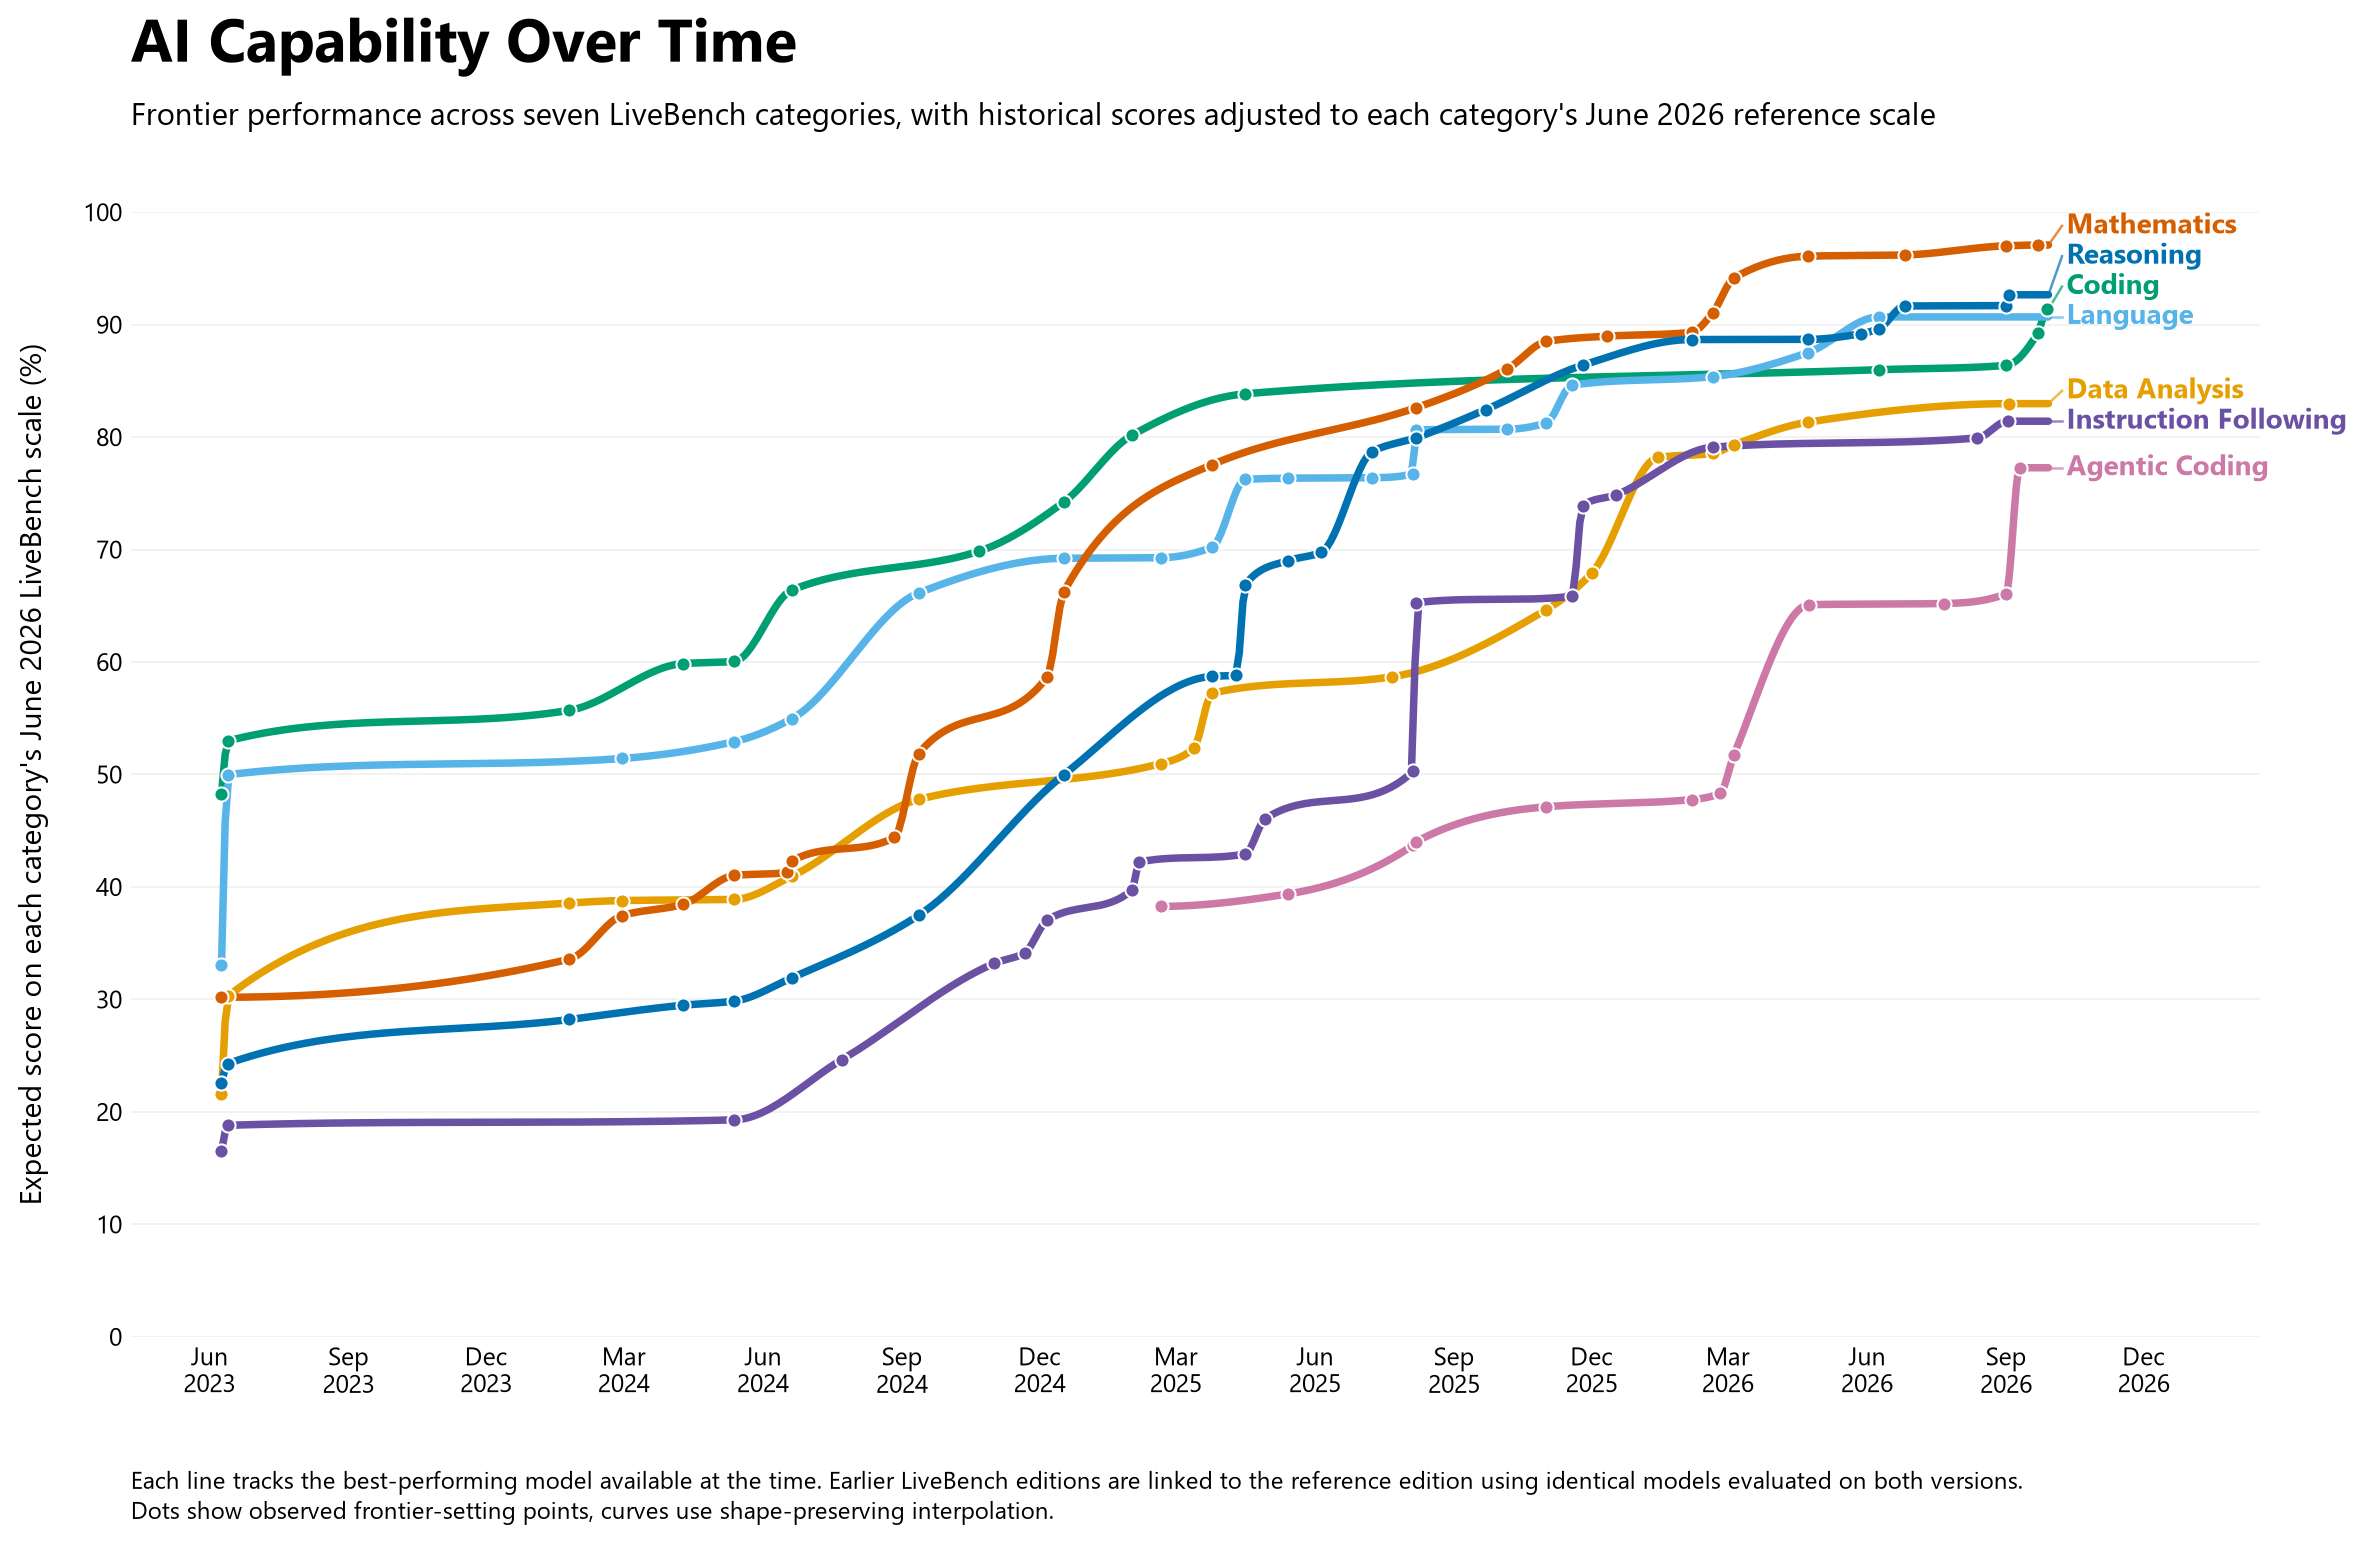

In [5]:
def prepare_plot_data(df):
    out = df.copy()
    out["category"] = out["category"].map(pretty_category)

    return (
        out
        .groupby(
            ["category", "model_release_date"],
            as_index=False,
        )["frontier_score"]
        .max()
        .sort_values(["category", "model_release_date"])
    )


plot_observed = prepare_plot_data(frontier_observed)
plot_display = prepare_plot_data(frontier_display)

fig, ax = plt.subplots(figsize=(14, 8.8), dpi=180)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

label_points = []


for category, line_data in plot_display.groupby("category"):

    line_data = line_data.sort_values("model_release_date")
    color = COLORS.get(category, "#444444")

    x = mdates.date2num(line_data["model_release_date"])
    y = line_data["frontier_score"].to_numpy()

    # Smooth line without overshooting monotonic frontier points.
    if len(line_data) >= 3:
        xs = np.linspace(x.min(), x.max(), 500)
        ys = PchipInterpolator(x, y)(xs)
        ax.plot(
            mdates.num2date(xs),
            ys,
            color=color,
            linewidth=3,
            solid_capstyle="round",
            zorder=2,
        )
    else:
        ax.plot(
            line_data["model_release_date"],
            y,
            color=color,
            linewidth=3,
            solid_capstyle="round",
            zorder=2,
        )

    # Only real frontier observations get dots.
    observed = plot_observed[
        plot_observed["category"] == category
    ]

    ax.scatter(
        observed["model_release_date"],
        observed["frontier_score"],
        s=32,
        color=color,
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
    )

    label_points.append({
        "category": category,
        "x": line_data["model_release_date"].iloc[-1],
        "y": y[-1],
        "color": color,
    })


# Spread crowded endpoint labels.
label_points = spread_labels(label_points, min_gap=2.7)
label_x = max(item["x"] for item in label_points) + pd.Timedelta(days=12)

for item in label_points:

    ax.plot(
        [item["x"], label_x - pd.Timedelta(days=3)],
        [item["y"], item["label_y"]],
        color=item["color"],
        linewidth=1,
        alpha=0.7,
        clip_on=False,
    )

    ax.text(
        label_x,
        item["label_y"],
        item["category"],
        color=item["color"],
        fontsize=11,
        fontweight="bold",
        va="center",
        ha="left",
        clip_on=False,
    )


# Axes and layout.
ax.set_ylim(0, 100)
ax.set_xlim(
    plot_display["model_release_date"].min() - pd.Timedelta(days=60),
    plot_display["model_release_date"].max() + pd.Timedelta(days=140),
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_yticks(np.arange(0, 101, 10))

ax.grid(axis="y", alpha=0.16)
ax.grid(axis="x", visible=False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0, labelsize=10)

ax.set_ylabel(
    "Expected score on each category's June 2026 LiveBench scale (%)",
    fontsize=12,
    labelpad=14,
)

fig.text(
    0.065,
    0.955,
    "AI Capability Over Time",
    fontsize=24,
    fontweight="bold",
    ha="left",
)

fig.text(
    0.065,
    0.915,
    "Frontier performance across seven LiveBench categories, "
    "with historical scores adjusted to each category's June 2026 reference scale",
    fontsize=12.5,
    ha="left",
)

fig.text(
    0.065,
    0.035,
    "Each line tracks the best-performing model available at the time. "
    "Earlier LiveBench editions are linked to the reference edition using "
    "identical models evaluated on both versions.\n"
    "Dots show observed frontier-setting points, curves use shape-preserving interpolation.",
    fontsize=9.5,
    ha="left",
    linespacing=1.35,
)

plt.subplots_adjust(
    left=0.065,
    right=0.91,
    top=0.86,
    bottom=0.15,
)

plt.savefig(
    "livebench_capability_frontier.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

## 6. Figure 2 — Logit-scale growth trends

Figure 2 uses **only `frontier_observed`** to fit each regression.

The display-only endpoints from Figure 1 are deliberately excluded, so they cannot
artificially flatten the fitted growth trends.

For presentation, the fitted regression lines are then **drawn to the same final
model-release date**. This makes their visual lengths comparable without adding
any new observations or changing the estimated slopes.


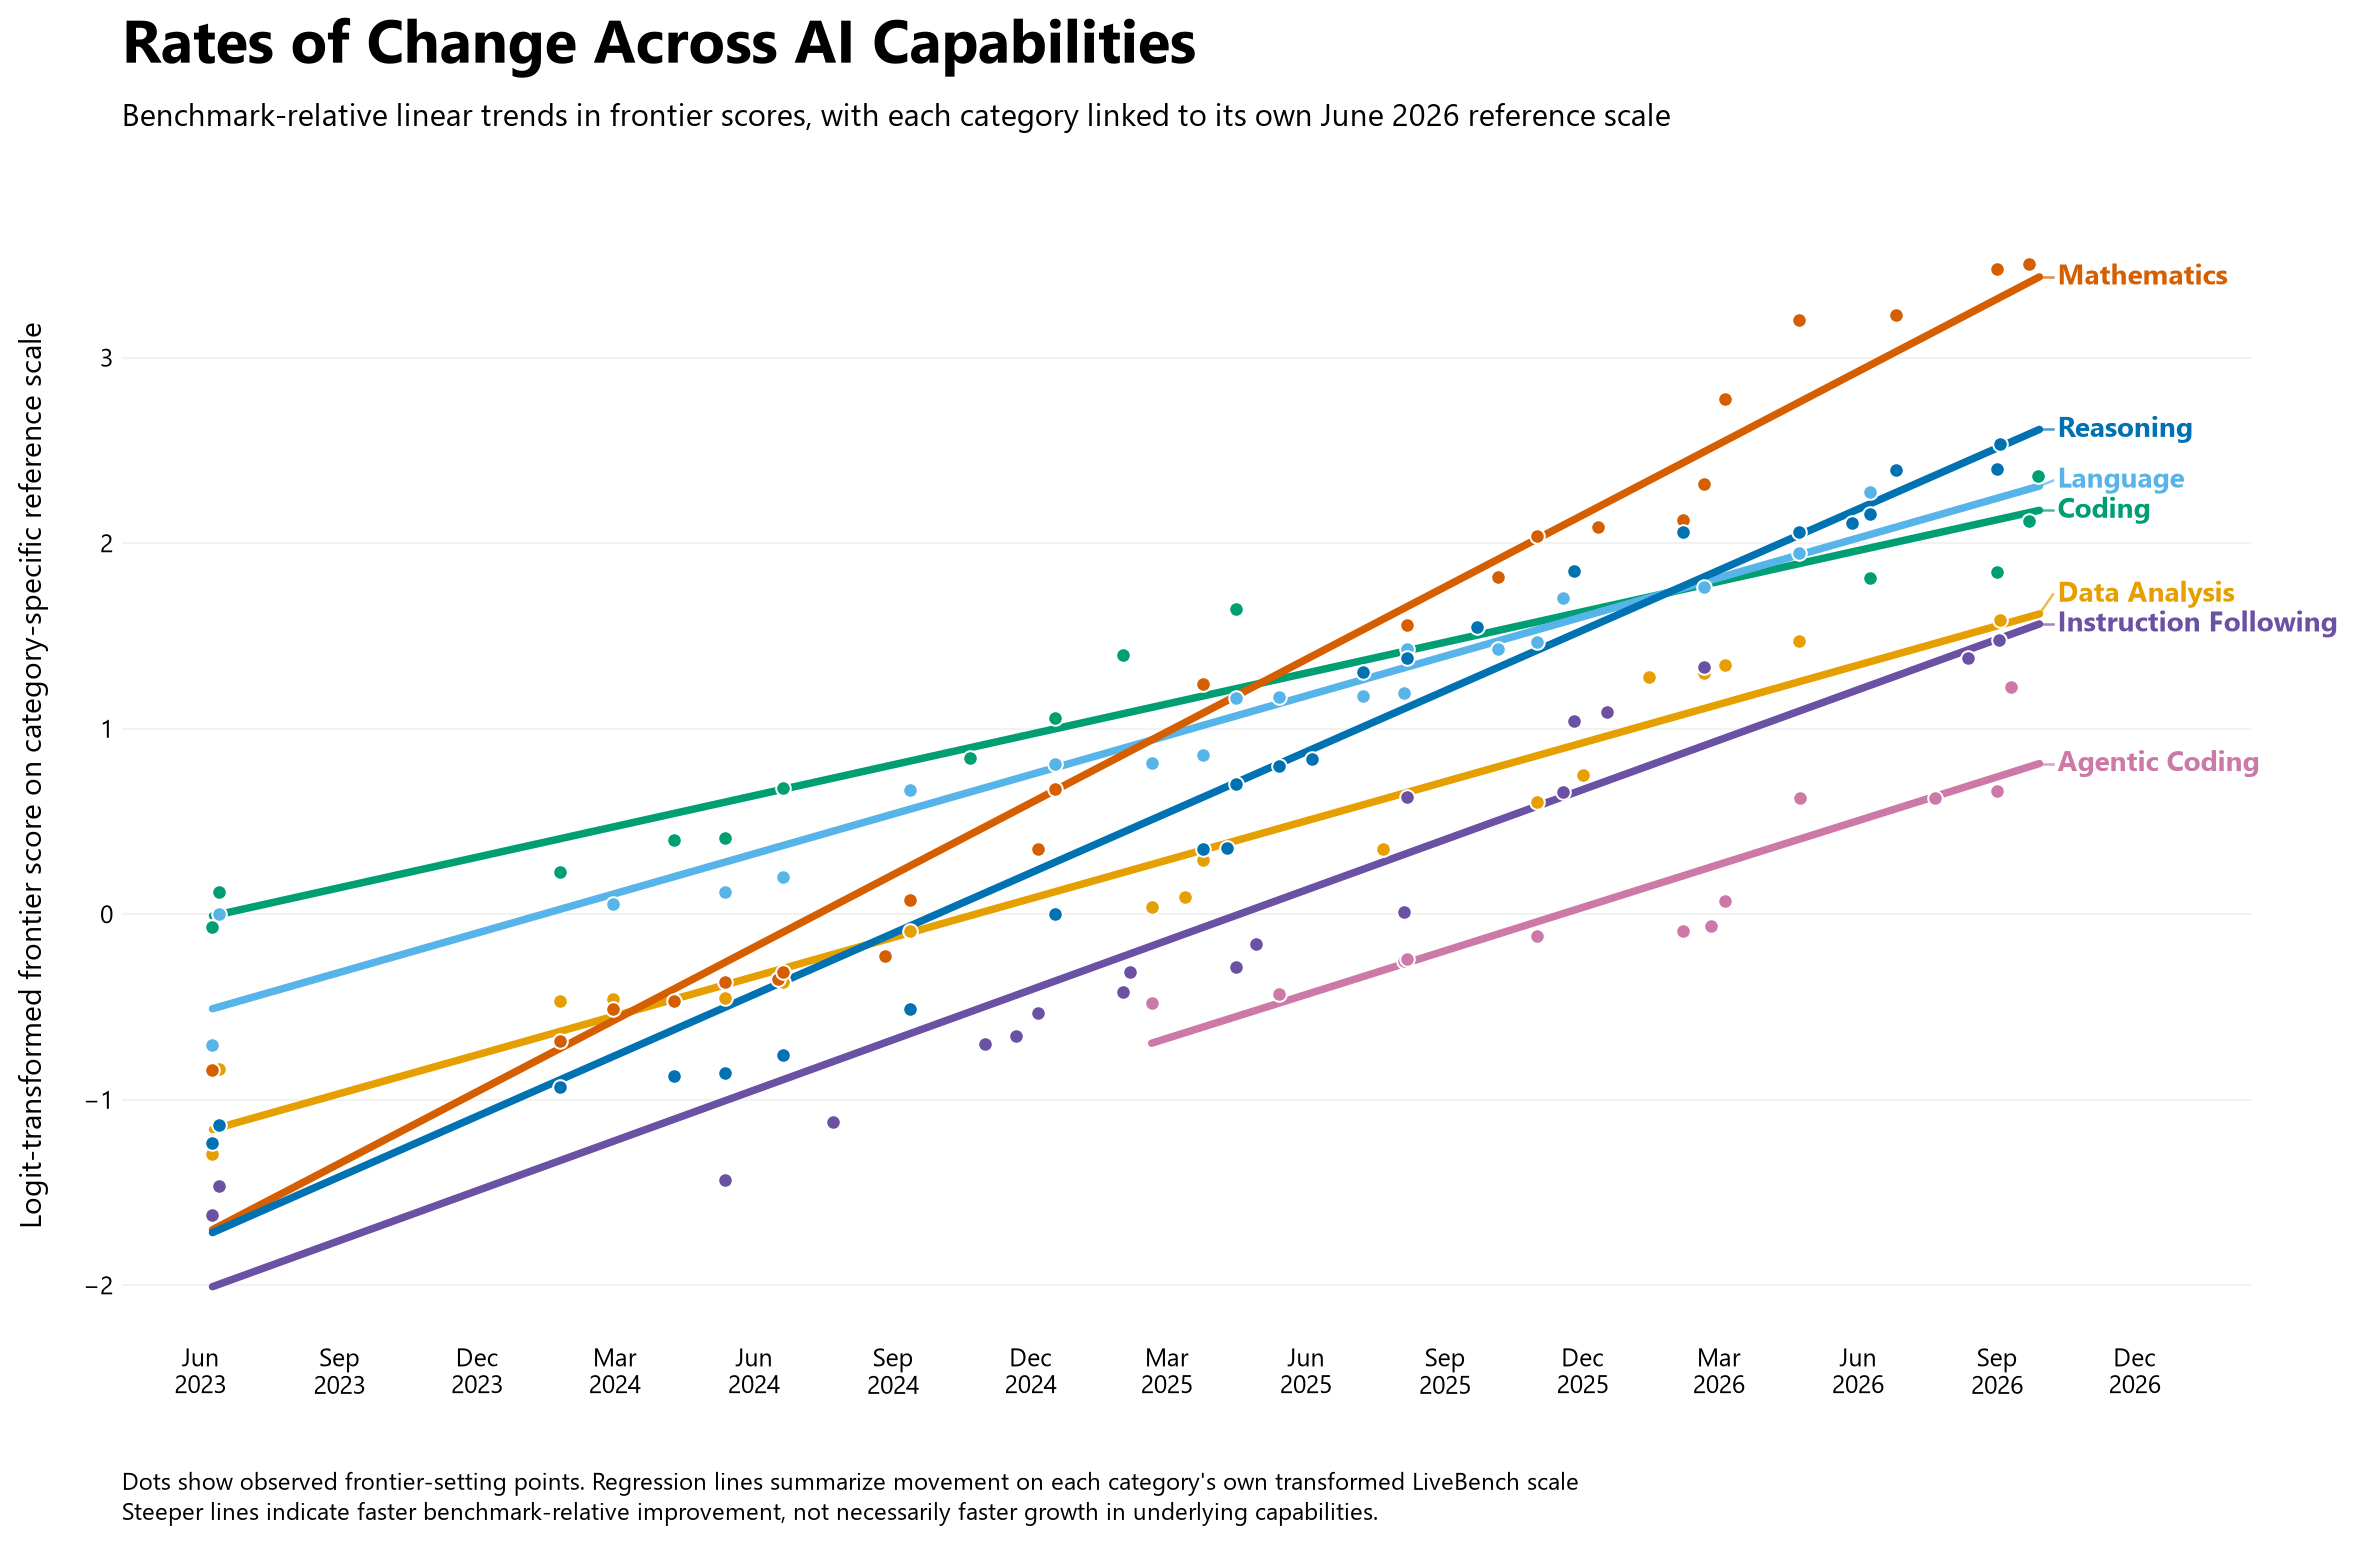

,category,logit_growth_per_year
5,Mathematics,1.552891
6,Reasoning,1.309013
3,Instruction Following,1.080099
0,Agentic Coding,0.937871
4,Language,0.851760
2,Data Analysis,0.840224
1,Coding,0.661020


In [6]:
logit_df = prepare_plot_data(frontier_observed)

# Draw every fitted trend line to the same final date.
# This affects only the visual extent of the line; the regression
# itself is still fitted only to real observed frontier points.
plot_end_date = models["model_release_date"].max()
plot_end_num = mdates.date2num(plot_end_date)

fig, ax = plt.subplots(figsize=(14, 8.8), dpi=180)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

label_points = []
growth_results = []


for category, d in logit_df.groupby("category"):

    d = d.sort_values("model_release_date")
    color = COLORS.get(category, "#444444")

    x = mdates.date2num(d["model_release_date"])
    y = score_to_logit(d["frontier_score"].to_numpy())

    slope, intercept = np.polyfit(x, y, 1)

    xs = np.linspace(x.min(), plot_end_num, 400)
    ys = intercept + slope * xs

    ax.scatter(
        d["model_release_date"],
        y,
        s=34,
        color=color,
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
    )

    ax.plot(
        mdates.num2date(xs),
        ys,
        color=color,
        linewidth=3,
        solid_capstyle="round",
        zorder=2,
    )

    final_y = intercept + slope * plot_end_num

    label_points.append({
        "category": category,
        "x": plot_end_date,
        "y": final_y,
        "color": color,
    })

    growth_results.append({
        "category": category,
        "logit_growth_per_year": slope * 365.25,
    })


# Spread crowded endpoint labels.
label_points = spread_labels(label_points, min_gap=0.16)
label_x = max(item["x"] for item in label_points) + pd.Timedelta(days=12)

for item in label_points:

    ax.plot(
        [item["x"], label_x - pd.Timedelta(days=3)],
        [item["y"], item["label_y"]],
        color=item["color"],
        linewidth=1,
        alpha=0.7,
        clip_on=False,
    )

    ax.text(
        label_x,
        item["label_y"],
        item["category"],
        color=item["color"],
        fontsize=11,
        fontweight="bold",
        va="center",
        ha="left",
        clip_on=False,
    )


growth_results = (
    pd.DataFrame(growth_results)
    .sort_values("logit_growth_per_year", ascending=False)
)

growth_results.to_csv(
    OUT / "livebench_logit_growth_rates.csv",
    index=False,
)


# Axes and layout.
ax.set_xlim(
    logit_df["model_release_date"].min() - pd.Timedelta(days=60),
    plot_end_date + pd.Timedelta(days=140),
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

ax.grid(axis="y", alpha=0.16)
ax.grid(axis="x", visible=False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0, labelsize=10)

ax.set_ylabel(
    "Logit-transformed frontier score on category-specific reference scale",
    fontsize=12,
    labelpad=14,
)

fig.text(
    0.065,
    0.955,
    "Rates of Change Across AI Capabilities",
    fontsize=24,
    fontweight="bold",
    ha="left",
)

fig.text(
    0.065,
    0.915,
    "Benchmark-relative linear trends in frontier scores, "
    "with each category linked to its own June 2026 reference scale",
    fontsize=12.5,
    ha="left",
)

fig.text(
    0.065,
    0.035,
    "Dots show observed frontier-setting points. "
    "Regression lines summarize movement on each category's own transformed LiveBench scale \n"
    "Steeper lines indicate faster benchmark-relative improvement, not necessarily faster growth in underlying capabilities.",
    fontsize=9.5,
    ha="left",
    linespacing=1.35
)

plt.subplots_adjust(
    left=0.065,
    right=0.91,
    top=0.86,
    bottom=0.15,
)

fig.savefig(
    "livebench_logit_growth.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

growth_results